# TMS Vertex Reconstruction & Validation — Fixed Notebook

This notebook reconstructs vertices for interactions inside the active TMS volume using **Reco_Tree** information and validates them with **Truth_Info**.

TMS bounds used here, in mm:
- X: `[-3730, +3730]`
- Y: `[-3100, +400]`
- Z: `[11124, 18544]`

Validation modes:
1. **Mode A: Truth-assisted grouping** — uses `RecoTrackPrimaryParticleVtxId` only for validation/upper-bound grouping.
2. **Mode B1: Reco-only nearest matching** — clusters tracks with reco geometry, then matches the reco vertex to the nearest true TMS vertex. This is optimistic because it minimizes residuals.
3. **Mode B2: Reco-only longest-track truth matching** — clusters tracks with reco geometry, then validates against the truth vertex ID of the longest track in the cluster. Use this as the fairer reco-only validation metric.

In [1]:
import uproot
import awkward as ak
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

plt.rcParams.update({
    "figure.figsize": (8, 5),
    "axes.titlesize": 14,
    "axes.labelsize": 12,
    "figure.dpi": 100,
})

print("Imports successful! ✓")

Imports successful! ✓


## 1. Load data

In [2]:
# Try common locations. Edit this list if your file lives elsewhere.
candidate_paths = [
    Path("../Cut2.root"),
    Path("Cut2.root"),
    Path("cut2.root"),
    Path(r"C:/MY_CODES/NIRAB_DAI/Cut2.root"),
]

file_path = next((p for p in candidate_paths if p.exists()), None)
if file_path is None:
    raise FileNotFoundError("Could not find Cut2.root. Edit candidate_paths in this cell.")

f = uproot.open(file_path)
t_rc = f["Reco_Tree;2"] if "Reco_Tree;2" in f else f["Reco_Tree"]
t_tr = f["Truth_Info;2"] if "Truth_Info;2" in f else f["Truth_Info"]

print("Opened:", file_path)
print("Reco entries:", t_rc.num_entries)
print("Truth entries:", t_tr.num_entries)

reco_branches = ["TrackHitPos", "nTracks"]
if "StartPos" in t_rc.keys():
    reco_branches.append("StartPos")
if "EndPos" in t_rc.keys():
    reco_branches.append("EndPos")

truth_branches = [
    "TrueVtxX", "TrueVtxY", "TrueVtxZ", "TrueVtxID",
    "RecoTrackPrimaryParticleVtxId",
]
if "RecoTrackPrimaryParticlePDG" in t_tr.keys():
    truth_branches.append("RecoTrackPrimaryParticlePDG")

rc_arr = t_rc.arrays(reco_branches)
tr_arr = t_tr.arrays(truth_branches)

n_events = min(len(rc_arr), len(tr_arr))
print("Loaded events:", n_events)
print("Reco branches loaded:", reco_branches)
print("Truth branches loaded:", truth_branches)

Opened: ..\Cut2.root
Reco entries: 1380
Truth entries: 1380
Loaded events: 1380
Reco branches loaded: ['TrackHitPos', 'nTracks', 'StartPos', 'EndPos']
Truth branches loaded: ['TrueVtxX', 'TrueVtxY', 'TrueVtxZ', 'TrueVtxID', 'RecoTrackPrimaryParticleVtxId', 'RecoTrackPrimaryParticlePDG']


## 2. Geometry and helper functions

In [3]:
TMS_X_MIN, TMS_X_MAX = -3730.0, 3730.0
TMS_Y_MIN, TMS_Y_MAX = -3100.0, 400.0
TMS_Z_MIN, TMS_Z_MAX = 11124.0, 18544.0


def is_inside_tms(x, y, z):
    return (
        TMS_X_MIN <= x <= TMS_X_MAX
        and TMS_Y_MIN <= y <= TMS_Y_MAX
        and TMS_Z_MIN <= z <= TMS_Z_MAX
    )


def valid_point(p):
    p = np.asarray(p, dtype=float)
    return p.shape == (3,) and np.all(np.isfinite(p)) and np.all(np.abs(p) < 1e7)


def get_truth_vertex_map(event_id):
    """Return {true_vtx_id: np.array([x,y,z])} for true vertices inside TMS."""
    xs = tr_arr["TrueVtxX"][event_id].tolist()
    ys = tr_arr["TrueVtxY"][event_id].tolist()
    zs = tr_arr["TrueVtxZ"][event_id].tolist()
    ids = tr_arr["TrueVtxID"][event_id].tolist()

    out = {}
    for v_id, x, y, z in zip(ids, xs, ys, zs):
        if is_inside_tms(x, y, z):
            out[int(v_id)] = np.array([x, y, z], dtype=float)
    return out


def get_track_truth_info(event_id, track_idx):
    """Return (truth_vertex_id, truth_pdg). pdg is None if unavailable."""
    vtx_ids = tr_arr["RecoTrackPrimaryParticleVtxId"][event_id].tolist()
    if track_idx >= len(vtx_ids):
        return None, None

    pdg = None
    if "RecoTrackPrimaryParticlePDG" in tr_arr.fields:
        pdgs = tr_arr["RecoTrackPrimaryParticlePDG"][event_id].tolist()
        if track_idx < len(pdgs):
            pdg = int(pdgs[track_idx])
    return int(vtx_ids[track_idx]), pdg


def fit_3d_line(hits):
    """Fit hits to a 3D line using SVD/PCA. Returns point, unit direction, mean squared residual."""
    hits = np.asarray(hits, dtype=float)
    if len(hits) < 2:
        p = hits[0] if len(hits) else np.zeros(3)
        return p, np.array([0.0, 0.0, 1.0]), np.nan

    mean = np.mean(hits, axis=0)
    centered = hits - mean

    try:
        _, _, vh = np.linalg.svd(centered, full_matrices=False)
        direction = vh[0]
    except np.linalg.LinAlgError:
        direction = hits[-1] - hits[0]
        norm = np.linalg.norm(direction)
        direction = direction / norm if norm > 0 else np.array([0.0, 0.0, 1.0])

    norm = np.linalg.norm(direction)
    direction = direction / norm if norm > 0 else np.array([0.0, 0.0, 1.0])

    start = hits[np.argmin(hits[:, 2])]
    end = hits[np.argmax(hits[:, 2])]
    if np.dot(direction, end - start) < 0:
        direction = -direction

    proj = centered - np.outer(centered @ direction, direction)
    residuals = np.sum(proj**2, axis=1)
    return mean, direction, float(np.mean(residuals))


def get_dca_line_to_line(p1, d1, p2, d2):
    """Return DCA and closest points between two infinite 3D lines."""
    p1 = np.asarray(p1, dtype=float)
    d1 = np.asarray(d1, dtype=float)
    p2 = np.asarray(p2, dtype=float)
    d2 = np.asarray(d2, dtype=float)

    n1 = np.linalg.norm(d1)
    n2 = np.linalg.norm(d2)
    if n1 == 0 or n2 == 0:
        return np.inf, p1, p2
    d1 = d1 / n1
    d2 = d2 / n2

    w0 = p1 - p2
    a = np.dot(d1, d1)
    b = np.dot(d1, d2)
    c = np.dot(d2, d2)
    d = np.dot(d1, w0)
    e = np.dot(d2, w0)
    denom = a * c - b * b

    if abs(denom) < 1e-8:
        pt1 = p1
        pt2 = p2 + np.dot(p1 - p2, d2) * d2
        return float(np.linalg.norm(pt1 - pt2)), pt1, pt2

    s = (b * e - c * d) / denom
    t = (a * e - b * d) / denom
    pt1 = p1 + s * d1
    pt2 = p2 + t * d2
    return float(np.linalg.norm(pt1 - pt2)), pt1, pt2


def reconstruct_vertex_from_lines(tracks, weighted=True):
    """Least-squares closest point to a set of track lines."""
    if len(tracks) == 0:
        return None
    if len(tracks) == 1:
        return tracks[0]["start"].copy()

    A = np.zeros((3, 3))
    b = np.zeros(3)

    for trk in tracks:
        p = trk["point"]
        d = trk["direction"]
        d = d / np.linalg.norm(d)
        proj = np.eye(3) - np.outer(d, d)

        if weighted:
            length = max(trk.get("length", 1.0), 1.0)
            resid = max(trk.get("residual", 1.0), 1.0)
            w = np.clip(np.sqrt(length) / np.sqrt(resid), 0.2, 5.0)
        else:
            w = 1.0

        A += w * proj
        b += w * (proj @ p)

    try:
        return np.linalg.solve(A, b)
    except np.linalg.LinAlgError:
        return np.mean([trk["start"] for trk in tracks], axis=0)

## 3. Extract reco tracks with original track indices preserved

In [4]:
def get_track_start_from_startpos(event_id, track_idx, hits):
    """Prefer Reco_Tree.StartPos if present and valid; otherwise use earliest-z hit."""
    if "StartPos" in rc_arr.fields:
        try:
            sp = np.asarray(rc_arr["StartPos"][event_id][track_idx], dtype=float)
            if sp.size >= 3:
                sp = sp[:3]
                if valid_point(sp) and is_inside_tms(sp[0], sp[1], sp[2]):
                    return sp
        except Exception:
            pass

    return hits[np.argmin(hits[:, 2])]


def extract_event_tracks(event_id, min_hits=2):
    tracks = []
    n_tracks = int(rc_arr["nTracks"][event_id])

    for track_idx in range(n_tracks):
        try:
            raw_hits = ak.to_numpy(rc_arr["TrackHitPos"][event_id][track_idx])
        except Exception:
            continue

        raw_hits = np.asarray(raw_hits, dtype=float)
        if raw_hits.ndim != 2 or raw_hits.shape[1] < 3:
            continue

        hits = raw_hits[:, :3]
        mask = (
            np.all(np.isfinite(hits), axis=1)
            & np.all(np.abs(hits) < 1e7, axis=1)
            & (hits[:, 0] > -9e8)
            & (hits[:, 2] > 0)
        )
        hits = hits[mask]
        if len(hits) < min_hits:
            continue

        p, d, residual = fit_3d_line(hits)
        start = get_track_start_from_startpos(event_id, track_idx, hits)
        end = hits[np.argmax(hits[:, 2])]

        if np.dot(d, end - start) < 0:
            d = -d

        length = float(np.linalg.norm(end - start))
        z_depth = float(np.max(hits[:, 2]) - np.min(hits[:, 2]))
        tv_id, pdg = get_track_truth_info(event_id, track_idx)

        tracks.append({
            "event_id": event_id,
            "track_idx": track_idx,
            "hits": hits,
            "point": p,
            "direction": d,
            "residual": residual,
            "start": start,
            "end": end,
            "length": length,
            "z_depth": z_depth,
            "n_hits": len(hits),
            "true_vtx_id": tv_id,
            "true_pdg": pdg,
        })

    return tracks

for eid in range(min(5, n_events)):
    print(eid, "n reco tracks extracted:", len(extract_event_tracks(eid)))

0 n reco tracks extracted: 2
1 n reco tracks extracted: 2
2 n reco tracks extracted: 2
3 n reco tracks extracted: 2
4 n reco tracks extracted: 2


## 4. Reco-only clustering

In [5]:
def passes_upstream_constraint(track_i, track_j, intersection, max_downstream_mm=150.0):
    """Require line crossing to be near/upstream of both track starts, not far downstream."""
    si = np.dot(intersection - track_i["start"], track_i["direction"])
    sj = np.dot(intersection - track_j["start"], track_j["direction"])
    return (si <= max_downstream_mm) and (sj <= max_downstream_mm)


def cluster_tracks_reco_only(
    tracks,
    start_dist_cut=400.0,
    dca_cut=150.0,
    use_upstream_constraint=True,
    max_downstream_mm=150.0,
):
    n = len(tracks)
    if n == 0:
        return []

    adj = np.eye(n, dtype=bool)
    for i in range(n):
        for j in range(i + 1, n):
            start_dist = np.linalg.norm(tracks[i]["start"] - tracks[j]["start"])
            dca, pt1, pt2 = get_dca_line_to_line(
                tracks[i]["point"], tracks[i]["direction"],
                tracks[j]["point"], tracks[j]["direction"],
            )
            mid = 0.5 * (pt1 + pt2)

            ok = (start_dist < start_dist_cut) and (dca < dca_cut)
            if ok and use_upstream_constraint:
                ok = passes_upstream_constraint(tracks[i], tracks[j], mid, max_downstream_mm)

            if ok:
                adj[i, j] = True
                adj[j, i] = True

    visited = np.zeros(n, dtype=bool)
    clusters = []

    for i in range(n):
        if visited[i]:
            continue
        comp = []
        queue = [i]
        visited[i] = True
        while queue:
            cur = queue.pop(0)
            comp.append(cur)
            for nb in range(n):
                if adj[cur, nb] and not visited[nb]:
                    visited[nb] = True
                    queue.append(nb)
        clusters.append([tracks[k] for k in comp])

    return clusters


def cluster_truth_purity(cluster):
    ids = [t["true_vtx_id"] for t in cluster if t["true_vtx_id"] is not None]
    if not ids:
        return np.nan, None
    vals, counts = np.unique(ids, return_counts=True)
    imax = np.argmax(counts)
    return counts[imax] / len(ids), int(vals[imax])

## 5. Run validation loop

In [6]:
records = []

for event_id in range(n_events):
    truth_vtx_map = get_truth_vertex_map(event_id)
    if len(truth_vtx_map) == 0:
        continue

    tracks = extract_event_tracks(event_id)
    if len(tracks) == 0:
        continue

    # Mode A: truth-assisted grouping
    truth_groups = {}
    for trk in tracks:
        tv_id = trk["true_vtx_id"]
        if tv_id in truth_vtx_map:
            truth_groups.setdefault(tv_id, []).append(trk)

    for tv_id, group_tracks in truth_groups.items():
        reco_vtx = reconstruct_vertex_from_lines(group_tracks, weighted=True)
        true_vtx = truth_vtx_map[tv_id]
        delta = reco_vtx - true_vtx

        records.append({
            "event_id": event_id,
            "true_vtx_id": tv_id,
            "match_mode": "truth_assisted",
            "grouping_mode": "Mode A: truth-assisted",
            "reco_vtx_x": reco_vtx[0], "reco_vtx_y": reco_vtx[1], "reco_vtx_z": reco_vtx[2],
            "true_vtx_x": true_vtx[0], "true_vtx_y": true_vtx[1], "true_vtx_z": true_vtx[2],
            "dx": delta[0], "dy": delta[1], "dz": delta[2], "dr": np.linalg.norm(delta),
            "n_tracks_in_vertex": len(group_tracks),
            "track_indices": tuple(t["track_idx"] for t in group_tracks),
            "cluster_purity": 1.0,
            "dominant_true_vtx_id": tv_id,
        })

    # Mode B: reco-only clustering
    clusters = cluster_tracks_reco_only(tracks)

    for cluster in clusters:
        reco_vtx = reconstruct_vertex_from_lines(cluster, weighted=True)
        purity, dominant_id = cluster_truth_purity(cluster)

        # Mode B1: nearest true TMS vertex. Optimistic / geometrically biased.
        nearest_tv_id = min(truth_vtx_map, key=lambda tv_id: np.linalg.norm(reco_vtx - truth_vtx_map[tv_id]))
        true_vtx = truth_vtx_map[nearest_tv_id]
        delta = reco_vtx - true_vtx

        records.append({
            "event_id": event_id,
            "true_vtx_id": nearest_tv_id,
            "match_mode": "nearest_truth_vertex",
            "grouping_mode": "Mode B1: reco-only nearest",
            "reco_vtx_x": reco_vtx[0], "reco_vtx_y": reco_vtx[1], "reco_vtx_z": reco_vtx[2],
            "true_vtx_x": true_vtx[0], "true_vtx_y": true_vtx[1], "true_vtx_z": true_vtx[2],
            "dx": delta[0], "dy": delta[1], "dz": delta[2], "dr": np.linalg.norm(delta),
            "n_tracks_in_vertex": len(cluster),
            "track_indices": tuple(t["track_idx"] for t in cluster),
            "cluster_purity": purity,
            "dominant_true_vtx_id": dominant_id,
        })

        # Mode B2: truth vertex of the longest track in the reco-only cluster. Fairer validation.
        longest = max(cluster, key=lambda t: t["length"])
        longest_tv_id = longest["true_vtx_id"]
        if longest_tv_id in truth_vtx_map:
            true_vtx = truth_vtx_map[longest_tv_id]
            delta = reco_vtx - true_vtx
            records.append({
                "event_id": event_id,
                "true_vtx_id": longest_tv_id,
                "match_mode": "longest_track_truth_vertex",
                "grouping_mode": "Mode B2: reco-only longest-track",
                "reco_vtx_x": reco_vtx[0], "reco_vtx_y": reco_vtx[1], "reco_vtx_z": reco_vtx[2],
                "true_vtx_x": true_vtx[0], "true_vtx_y": true_vtx[1], "true_vtx_z": true_vtx[2],
                "dx": delta[0], "dy": delta[1], "dz": delta[2], "dr": np.linalg.norm(delta),
                "n_tracks_in_vertex": len(cluster),
                "track_indices": tuple(t["track_idx"] for t in cluster),
                "cluster_purity": purity,
                "dominant_true_vtx_id": dominant_id,
            })


df = pd.DataFrame(records)
df.to_csv("tms_vertex_validation_fixed.csv", index=False)
print(f"Validation complete. Saved {len(df)} records to tms_vertex_validation_fixed.csv")
df.head()

Validation complete. Saved 7440 records to tms_vertex_validation_fixed.csv


,event_id,true_vtx_id,match_mode,grouping_mode,reco_vtx_x,reco_vtx_y,reco_vtx_z,true_vtx_x,true_vtx_y,true_vtx_z,dx,dy,dz,dr,n_tracks_in_vertex,track_indices,cluster_purity,dominant_true_vtx_id
0,0,100,truth_assisted,Mode A: truth-assisted,-2459.135742,-1828.563477,13673.0,-2445.734375,-1615.436279,13623.612305,-13.401367,-213.127197,49.387695,219.184724,1,"(0,)",1.0,100
1,0,102,truth_assisted,Mode A: truth-assisted,-853.162598,-1399.562256,15273.0,-828.278198,-2077.431885,15484.220703,-24.884399,677.869629,-211.220703,710.451021,1,"(1,)",1.0,102
2,0,100,nearest_truth_vertex,Mode B1: reco-only nearest,-2459.135742,-1828.563477,13673.0,-2445.734375,-1615.436279,13623.612305,-13.401367,-213.127197,49.387695,219.184724,1,"(0,)",1.0,100
3,0,100,longest_track_truth_vertex,Mode B2: reco-only longest-track,-2459.135742,-1828.563477,13673.0,-2445.734375,-1615.436279,13623.612305,-13.401367,-213.127197,49.387695,219.184724,1,"(0,)",1.0,100
4,0,35,nearest_truth_vertex,Mode B1: reco-only nearest,-853.162598,-1399.562256,15273.0,-952.013611,-1109.880859,15244.057617,98.851013,-289.681396,28.942383,307.448363,1,"(1,)",1.0,102


## 6. Summaries

In [9]:
def summarize(sub_df, name):
    print("" + "=" * 80)
    print(f"{name}: N={len(sub_df)}")
    print("=" * 80)
    if len(sub_df) == 0:
        return

    for c in ["dx", "dy", "dz", "dr"]:
        print(
            f"{c:>2}: mean={sub_df[c].mean():9.2f} mm, "
            f"std={sub_df[c].std():9.2f} mm, "
            f"median_abs={np.median(np.abs(sub_df[c])):9.2f} mm"
        )

    print("Fraction within dr bound:")
    for d in [50, 100, 200, 500, 1000]:
        print(f"  {d:4d} mm: {(sub_df['dr'] < d).mean() * 100:6.2f}%")

    print("Track multiplicity:")
    print(sub_df["n_tracks_in_vertex"].value_counts().sort_index())

    if "cluster_purity" in sub_df:
        print("luster purity:")
        print(sub_df["cluster_purity"].describe())

for mode, sub in df.groupby("grouping_mode"):
    summarize(sub, mode)

Mode A: truth-assisted: N=1923
dx: mean=     0.16 mm, std=    89.13 mm, median_abs=    29.66 mm
dy: mean=   -41.32 mm, std=   514.16 mm, median_abs=   211.22 mm
dz: mean=    97.35 mm, std=   604.42 mm, median_abs=   116.21 mm
dr: mean=   522.49 mm, std=   612.93 mm, median_abs=   348.92 mm
Fraction within dr bound:
    50 mm:   3.07%
   100 mm:  11.54%
   200 mm:  27.56%
   500 mm:  63.65%
  1000 mm:  87.94%
Track multiplicity:
n_tracks_in_vertex
1    1106
2     762
3      54
4       1
Name: count, dtype: int64
luster purity:
count    1923.0
mean        1.0
std         0.0
min         1.0
25%         1.0
50%         1.0
75%         1.0
max         1.0
Name: cluster_purity, dtype: float64
Mode B1: reco-only nearest: N=2818
dx: mean=    -3.20 mm, std=   201.16 mm, median_abs=    37.04 mm
dy: mean=     6.68 mm, std=   343.52 mm, median_abs=   212.17 mm
dz: mean=   -48.29 mm, std=   235.57 mm, median_abs=    78.40 mm
dr: mean=   377.22 mm, std=   272.03 mm, median_abs=   307.40 mm
Fraction

## 7. Reco-vs-true coordinate scatter

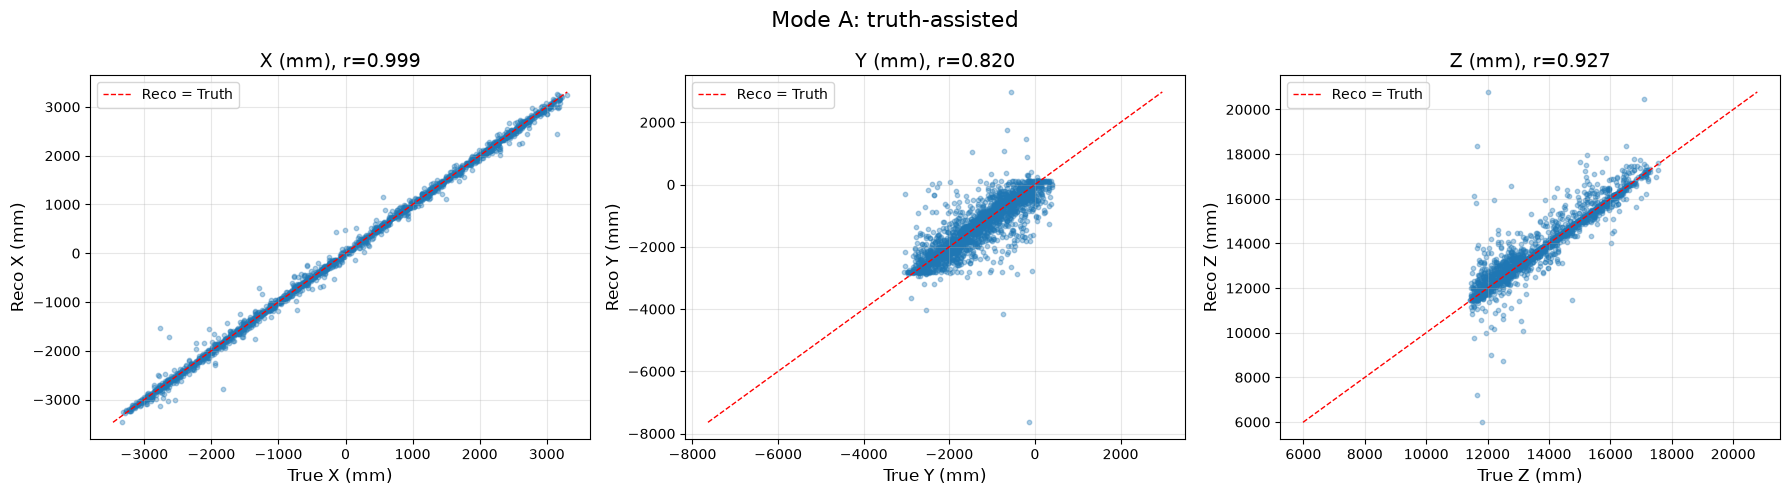

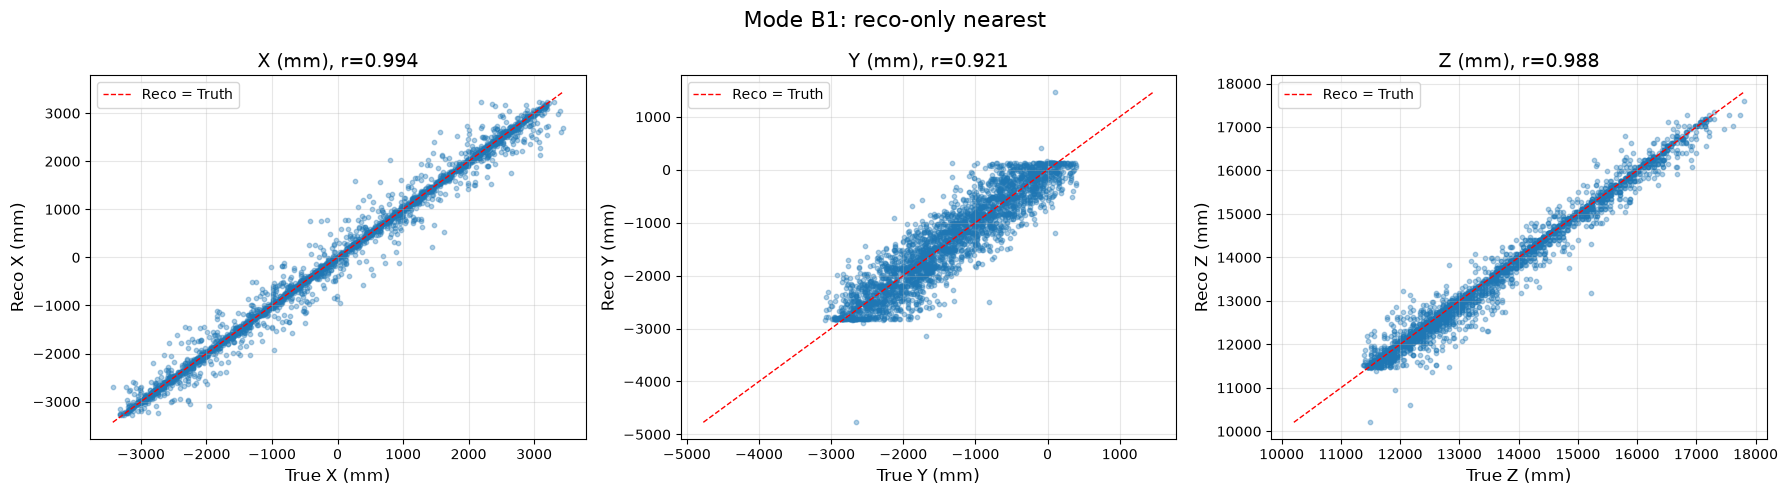

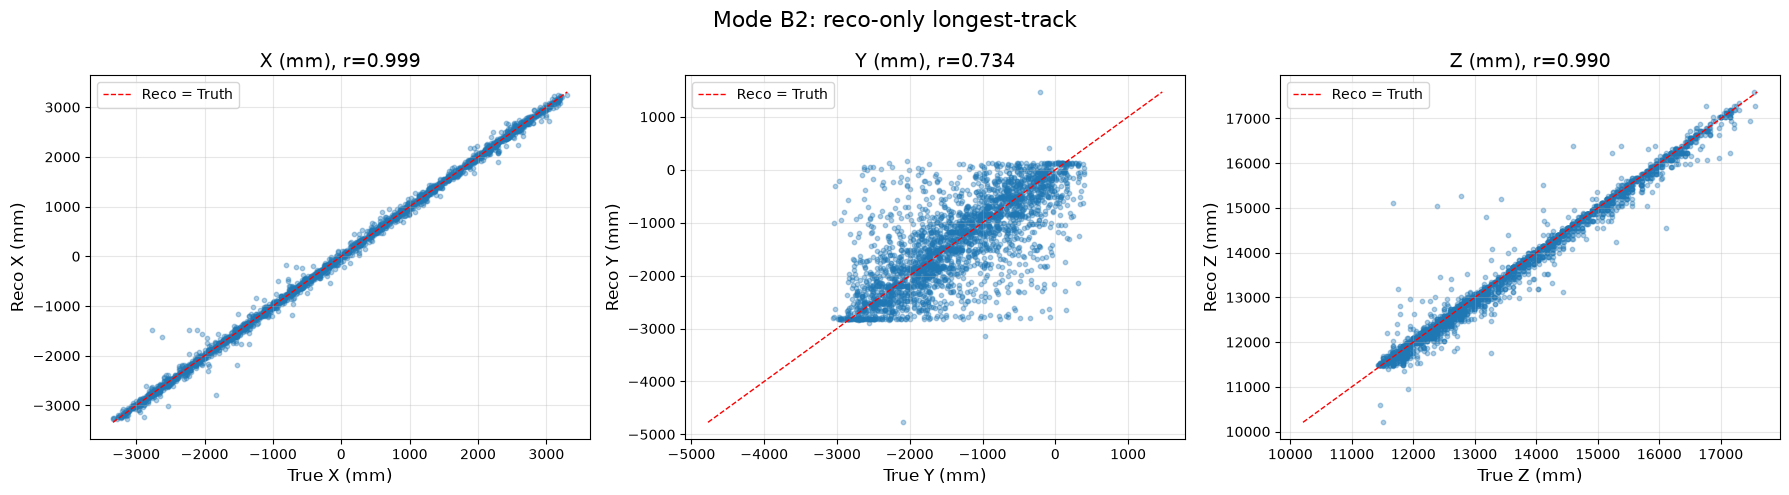

In [10]:
def plot_reco_true_scatter(sub_df, title):
    if len(sub_df) == 0:
        print("No entries for", title)
        return

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    coords = [
        ("true_vtx_x", "reco_vtx_x", "X (mm)"),
        ("true_vtx_y", "reco_vtx_y", "Y (mm)"),
        ("true_vtx_z", "reco_vtx_z", "Z (mm)"),
    ]

    for ax, (tc, rc, lab) in zip(axes, coords):
        ax.scatter(sub_df[tc], sub_df[rc], alpha=0.35, s=10)
        lo = min(sub_df[tc].min(), sub_df[rc].min())
        hi = max(sub_df[tc].max(), sub_df[rc].max())
        ax.plot([lo, hi], [lo, hi], "r--", linewidth=1, label="Reco = Truth")

        if len(sub_df) > 2:
            corr = np.corrcoef(sub_df[tc], sub_df[rc])[0, 1]
        else:
            corr = np.nan
        ax.set_title(f"{lab}, r={corr:.3f}")
        ax.set_xlabel("True " + lab)
        ax.set_ylabel("Reco " + lab)
        ax.grid(True, alpha=0.3)
        ax.legend()

    fig.suptitle(title, fontsize=16)
    plt.tight_layout()
    plt.show()

for mode in df["grouping_mode"].unique():
    plot_reco_true_scatter(df[df["grouping_mode"] == mode], mode)

## 8. Resolution vs track multiplicity

 Mode A: truth-assisted
                    count        mean      median
n_tracks_in_vertex                               
1                    1106  361.947143  244.146326
2                     762  742.907116  536.974961
3                      54  692.889392  562.619761
4                       1  922.504905  922.504905


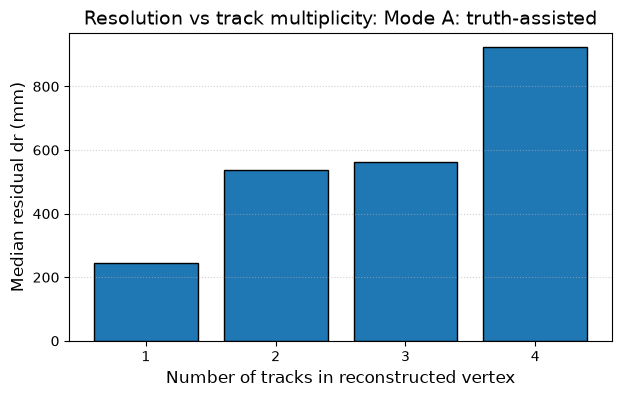

 Mode B1: reco-only nearest
                    count        mean      median
n_tracks_in_vertex                               
1                    2722  376.264548  307.670415
2                      95  407.078196  307.345129
3                       1  149.268709  149.268709


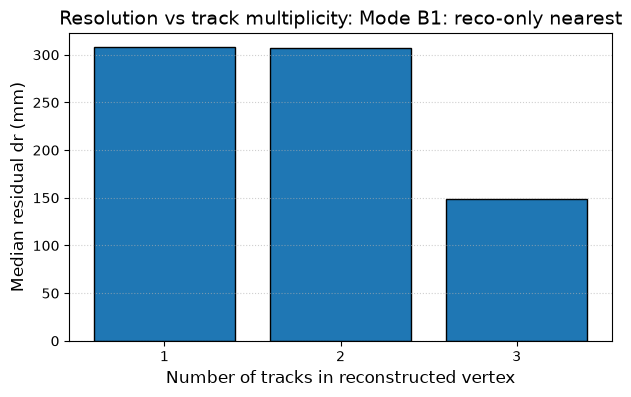

 Mode B2: reco-only longest-track
                    count        mean      median
n_tracks_in_vertex                               
1                    2603  469.998197  317.781487
2                      95  459.945379  322.489427
3                       1  149.268709  149.268709


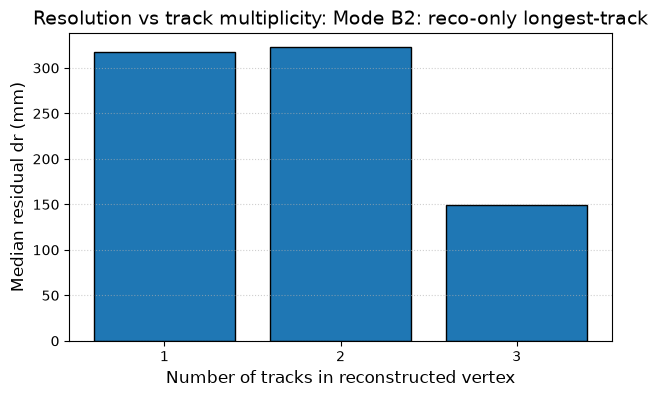

In [11]:
for mode in df["grouping_mode"].unique():
    sub = df[df["grouping_mode"] == mode]
    stats = sub.groupby("n_tracks_in_vertex")["dr"].agg(["count", "mean", "median"])
    print("", mode)
    print(stats)

    plt.figure(figsize=(7, 4))
    plt.bar(stats.index.astype(str), stats["median"], edgecolor="black")
    plt.xlabel("Number of tracks in reconstructed vertex")
    plt.ylabel("Median residual dr (mm)")
    plt.title(f"Resolution vs track multiplicity: {mode}")
    plt.grid(axis="y", linestyle=":", alpha=0.6)
    plt.show()

## 9. 3D display of matched reco/true vertices

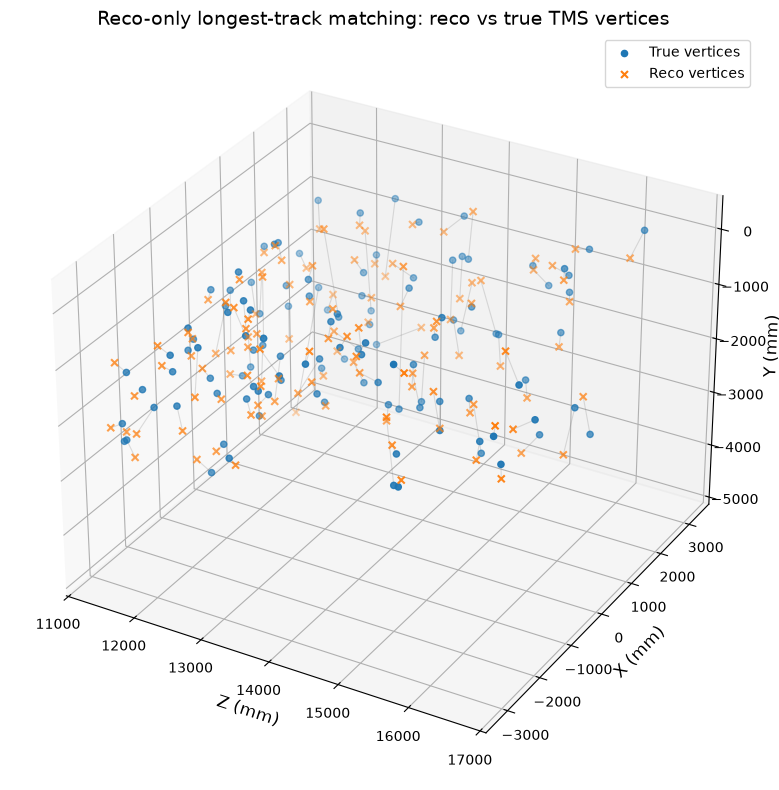

In [12]:
def plot_3d_pairs(sub_df, title, n_sample=120):
    if len(sub_df) == 0:
        print("No entries for", title)
        return
    sample = sub_df.sample(min(n_sample, len(sub_df)), random_state=42)

    fig = plt.figure(figsize=(10, 8))
    ax = fig.add_subplot(111, projection="3d")

    ax.scatter(sample["true_vtx_z"], sample["true_vtx_x"], sample["true_vtx_y"],
               marker="o", s=20, label="True vertices")
    ax.scatter(sample["reco_vtx_z"], sample["reco_vtx_x"], sample["reco_vtx_y"],
               marker="x", s=25, label="Reco vertices")

    for _, row in sample.iterrows():
        ax.plot(
            [row["true_vtx_z"], row["reco_vtx_z"]],
            [row["true_vtx_x"], row["reco_vtx_x"]],
            [row["true_vtx_y"], row["reco_vtx_y"]],
            color="gray", alpha=0.25, linewidth=0.8,
        )

    ax.set_xlabel("Z (mm)")
    ax.set_ylabel("X (mm)")
    ax.set_zlabel("Y (mm)")
    ax.set_title(title)
    ax.legend()
    plt.tight_layout()
    plt.show()

plot_3d_pairs(df[df["grouping_mode"] == "Mode B2: reco-only longest-track"],
              "Reco-only longest-track matching: reco vs true TMS vertices")

## 10. Optional: global bias correction check

In [13]:
# This is a simple check for whether a global dx/dy/dz calibration would improve resolution.
# Fit correction only on Mode B2, because that is the fairer reco-only validation mode.
sub = df[df["grouping_mode"] == "Mode B2: reco-only longest-track"].copy()
if len(sub) > 0:
    bias = sub[["dx", "dy", "dz"]].mean().to_numpy()
    reco = sub[["reco_vtx_x", "reco_vtx_y", "reco_vtx_z"]].to_numpy()
    true = sub[["true_vtx_x", "true_vtx_y", "true_vtx_z"]].to_numpy()

    reco_corr = reco - bias
    dr_before = np.linalg.norm(reco - true, axis=1)
    dr_after = np.linalg.norm(reco_corr - true, axis=1)

    print("Mode B2 global bias:", bias)
    print(f"Median dr before: {np.median(dr_before):.2f} mm")
    print(f"Median dr after : {np.median(dr_after):.2f} mm")
    print(f"Mean dr before  : {np.mean(dr_before):.2f} mm")
    print(f"Mean dr after   : {np.mean(dr_after):.2f} mm")
else:
    print("No Mode B2 entries available.")

Mode B2 global bias: [  0.25028349 -14.79852161 -42.04800103]
Median dr before: 317.78 mm
Median dr after : 311.96 mm
Mean dr before  : 469.53 mm
Mean dr after   : 468.63 mm
